# Access Sentinel-1 in Analysis Mode

**xarray-eopf** is a Python package that extends **xarray** with a custom backend called `"eopf-zarr"`. This backend enables **seamless access to ESA EOPF data products** stored in the **Zarr** format, presenting them as analysis-ready data structures.

In this notebook, we demonstrate how to use the **xarray-eopf** backend to access **Sentinel-1** EOPF Zarr products in **analysis mode**. All data access is *lazy*, meaning that data is only loaded when required—for example, during plotting or when writing to storage.

For a general introduction to the xarray EOPF backend, see the [introduction notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/introduction/).
For an example of the native mode, see the [Sentinel-1 native mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_1_native/).


- 🐙 **GitHub:** [EOPF Sample Service – xarray-eopf](https://github.com/EOPF-Sample-Service/xarray-eopf)
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xarray-eopf/issues)
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xarray-eopf/)

## Main Features of the Analysis Mode for Sentinel-1

The Sentinel-1 analysis workflow covers:

* [**GRD products**](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-grd)
* [**SLC products**](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-slc)
* [**OCN products**](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l2-ocn)

### Sentinel-1 GRD

Sentinel-1 GRD data is provided in radar geometry, defined by the coordinates (`azimuth_time`, `ground_range`). To transform this data into an **analysis-ready dataset**, several processing steps are required:

1. **Radiometric Calibration:** Raw pixel values (DN) are converted into physically meaningful backscatter values using the `beta_nought` calibration lookup table (LUT).
2. **Geometric Terrain Correction (GTC):** Using a Digital Elevation Model (DEM), the processor performs **inverse geocoding** by solving the zero-Doppler equation based on satellite orbit information and terrain elevation. This step maps the data from radar geometry to a georeferenced grid.
3. **Radiometric Terrain Correction (RTC):** RTC compensates for terrain-induced radiometric distortions such as foreshortening, layover, and slope-dependent brightness variations.

**References**

📖 [D. Small, *Flattening Gamma: Radiometric Terrain Correction for SAR Imagery*](https://ieeexplore.ieee.org/document/5752845)


### Sentinel-1 SLC

Sentinel-1 SLC data is provided in individual bursts and swaths as complex datatype provided in radar geometry, defined by the coordinates (`azimuth_time`, `slant_range_time`). To transform this data into an **analysis-ready dataset**, several processing steps are required:

1. **Radiometric Calibration:** Raw pixel values (DN) are converted into physically meaningful backscatter values using the `beta_nought` calibration lookup table (LUT). This is performed for each burst. The complex data is transformed into amplitude (`abs(slc)`)-
2. **TOPSAR:** The data is debursted, meaning that individual bursts are aligned with each other and concatenated along azimuth time and slant range time, where valid ranges are identified using meta data, and overlaps are cut off.
3. **Geometric Terrain Correction (GTC):** as in [Sentinel-1 GRD workflow](#sentinel-1-grd)
4. **Radiometric Terrain Correction (RTC):** as in [Sentinel-1 GRD workflow](#sentinel-1-grd)

### Sentinel-1 OCN

Sentinel-1 OCN data is provides in a geographic grid, where each pixel is defined by a latitude/longitude pair, forming a 2D curvilinear (irregular) grid.

The analysis mode applies the [rectification algorithm in xcube-resampling](https://xcube-dev.github.io/xcube-resampling/guide/#3-rectification) to transform this irregular grid into a **regular (rectilinear) grid** with 1D latitude and longitude coordinates.

### Key properties of Sentinel-1

- **Default mode** for the `"eopf-zarr"` backend
- **Configurable interpolation:** controlled via `interp_methods`; supported methods: `nearest`, `bilinear`
- **Flexible variable selection:** select variables by explicit names or regex patterns

#### Key properties specific for GRD amd SLC

- **Flexible target grid definition**
  - Provide a DEM directly via the `dem` parameter (`xarray.DataArray`)
  - Or define the grid using `resolution`, `crs`, and `bbox`
  - If no DEM is provided, the
    [CopDEM COG (30 m)](https://browser.stac.dataspace.copernicus.eu/collections/cop-dem-glo-30-dged-cog)
    is automatically retrieved via the CDSE STAC API, which requires [CDSE S3 credentials](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets)
- **Radiometric Terrain Correction (RTC)** can be disabled using `apply_rtc=False`
- **Footprint scaling:** controlled via `footprint_scale_factor`; defines how radar pixels contribute to the output grid;
    - GRD default: `(3.0, 3.0)` which accounts for resolution differences (e.g., ~10 m GRD vs. ~30 m DEM).
    - SLC default: `(3.0, 15.0)` which accounts for resolution differences (e.g., (~10 m, ~2 m) SLC vs. ~30 m DEM).

#### Key properties specific for OCN

- **Rectification**: converts the 2D curvilinear grid into a rectilinear grid
- **Spatial subsetting** via the `bbox` argument
- **Reprojection** to different CRS via the `crs` argument (default: WGS84, EPSG:4326)


For full details on opening parameters, see the [Analysis Mode documentation](https://eopf-sample-service.github.io/xarray-eopf/guide/#analysis-mode) and, specifically for Sentinel-1, the [Sentinel-1 Analysis Mode guide](https://eopf-sample-service.github.io/xarray-eopf/guide/#sentinel-1).

---

## Import Modules

The `eopf-zarr` backend is registered as an `xarray` plugin. Import `xarray` as usual, plus helper libraries used in this notebook.


In [1]:
import os

import matplotlib.pyplot as plt
import pystac_client
import xarray as xr
from xcube_resampling.utils import reproject_bbox

---

## Open a Sentinel-1 Level-1 GRD Product in Analysis Mode

We begin with an example that accesses a Sentinel-1 Level-1 GRD product in **analysis mode**.


### Find a Sentinel-1 GRD Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-grd) to search for a Sentinel-1 GRD tile.

In [2]:
bbox = [5.3, 43.1, 5.7, 43.4]
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=bbox,
        datetime=["2026-04-16", "2026-04-16"],
    ).items()
)
items

[<Item id=S1A_IW_GRDH_1SDV_20260416T173048_20260416T173113_064108_08114E_92D0>]

In [3]:
item = items[0]
item

<Item id=S1A_IW_GRDH_1SDV_20260416T173048_20260416T173113_064108_08114E_92D0>

### Open Sentinel-1 GRD with default parameters

We can now open the Sentinel-1 product in **analysis mode**. Since this is the default, the `op_mode` parameter does not need to be specified.

The following cell returns a **lazy dataset**. For demonstration purposes, we restrict the data to a small spatial subset by specifying a bounding box.

Before proceeding, CDSE S3 credentials must be configured to enable access to the CopDEM (30 m) dataset from CDSE. Instructions for generating credentials are available [here](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets).

In [4]:
os.environ.update(
    {
        "AWS_ACCESS_KEY_ID": "xxx",
        "AWS_SECRET_ACCESS_KEY": "xxx",
    }
)

In [5]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    bbox=bbox,
    chunks={}
)
ds

<xarray.Dataset> Size: 12MB
Dimensions:      (lat: 1081, lon: 1441)
Coordinates:
  * lat          (lat) float64 9kB 43.4 43.4 43.4 43.4 ... 43.1 43.1 43.1 43.1
  * lon          (lon) float64 12kB 5.3 5.3 5.301 5.301 ... 5.699 5.699 5.7 5.7
    spatial_ref  int64 8B ...
Data variables:
    gamma0_vv    (lat, lon) float32 6MB dask.array<chunksize=(1081, 1441), meta=np.ndarray>
    gamma0_vh    (lat, lon) float32 6MB dask.array<chunksize=(1081, 1441), meta=np.ndarray>

As an example, we plot the calibrated VV polarization band. Plotting triggers lazy loading and computation.

/home/konstantin/micromamba/envs/xarray-eopf/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


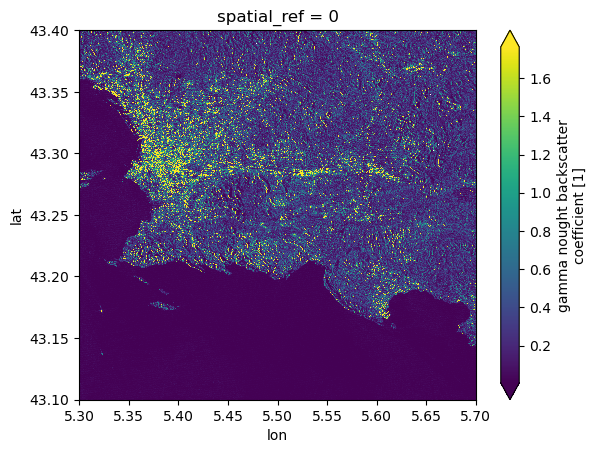

In [6]:
ds.gamma0_vv.plot(robust=True)

### Open Sentinel-1 GRD in UTM grid

In the following we show different ways to open a Sentinel-1 GRD product in analysis mode.

We can define the target gridmapping in UTM using the `resolution`, `crs`,and `bbox` parameters.


In [7]:
crs_utm = "EPSG:32631"
bbox_utm = reproject_bbox(bbox, "EPSG:4326", "EPSG:32631")

ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    bbox=bbox_utm,
    crs=crs_utm,
    resolution=30, # meters
    chunks={}
)
ds

<xarray.Dataset> Size: 10MB
Dimensions:      (x: 1116, y: 1143)
Coordinates:
  * x            (x) float64 9kB 6.863e+05 6.863e+05 ... 7.197e+05 7.197e+05
  * y            (y) float64 9kB 4.809e+06 4.809e+06 ... 4.775e+06 4.775e+06
    spatial_ref  int64 8B ...
Data variables:
    gamma0_vv    (y, x) float32 5MB dask.array<chunksize=(1143, 1116), meta=np.ndarray>
    gamma0_vh    (y, x) float32 5MB dask.array<chunksize=(1143, 1116), meta=np.ndarray>

We can again visualize one polarization channel (for example `vv`).

/home/konstantin/micromamba/envs/xarray-eopf/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


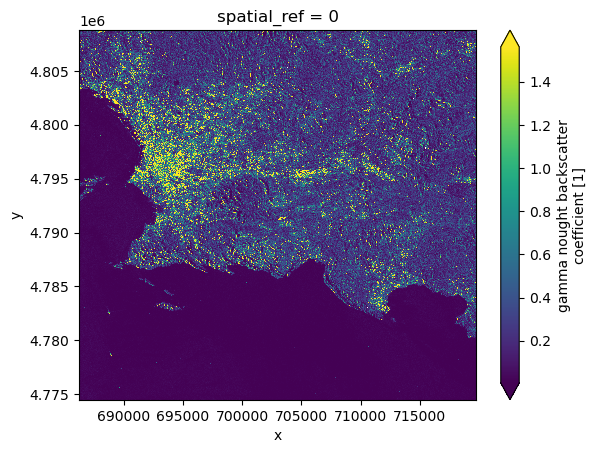

In [8]:
ds.gamma0_vv.plot(robust=True)

### Turn off radiometric terrain correction (RTC)

In the next example we turn off the RTC and select on the vv band.

In [9]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    bbox=bbox,
    variables=["vv"],
    apply_rtc=False,
    chunks={}
)
ds

<xarray.Dataset> Size: 6MB
Dimensions:      (lat: 1081, lon: 1441)
Coordinates:
  * lat          (lat) float64 9kB 43.4 43.4 43.4 43.4 ... 43.1 43.1 43.1 43.1
  * lon          (lon) float64 12kB 5.3 5.3 5.301 5.301 ... 5.699 5.699 5.7 5.7
    spatial_ref  int64 8B ...
Data variables:
    beta0_vv     (lat, lon) float32 6MB dask.array<chunksize=(1081, 1441), meta=np.ndarray>

In the following plot you can clearly see the structure of the mountainous terrain, since the backscatter variation has not been corrected for the terrain.

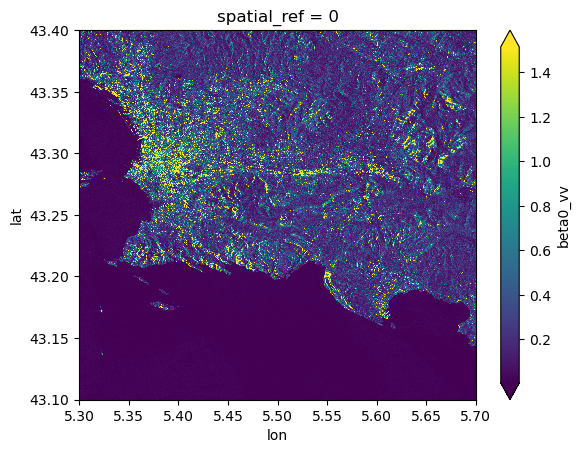

In [10]:
ds.beta0_vv.plot(robust=True)

### Interpolation Method: Nearest Neighbor

In the next example, we set the interpolation method to `nearest`, which is applied during both Geometric Terrain Correction (GTC) and Radiometric Terrain Correction (RTC).

This approach improves computational performance but reduces accuracy compared to bilinear interpolation, as it avoids spatial smoothing and instead assigns the value of the closest pixel.

In [11]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    bbox=bbox,
    interp_methods="nearest",
    chunks={}
)
ds

<xarray.Dataset> Size: 12MB
Dimensions:      (lat: 1081, lon: 1441)
Coordinates:
  * lat          (lat) float64 9kB 43.4 43.4 43.4 43.4 ... 43.1 43.1 43.1 43.1
  * lon          (lon) float64 12kB 5.3 5.3 5.301 5.301 ... 5.699 5.699 5.7 5.7
    spatial_ref  int64 8B ...
Data variables:
    gamma0_vv    (lat, lon) float32 6MB dask.array<chunksize=(1081, 1441), meta=np.ndarray>
    gamma0_vh    (lat, lon) float32 6MB dask.array<chunksize=(1081, 1441), meta=np.ndarray>

/home/konstantin/micromamba/envs/xarray-eopf/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


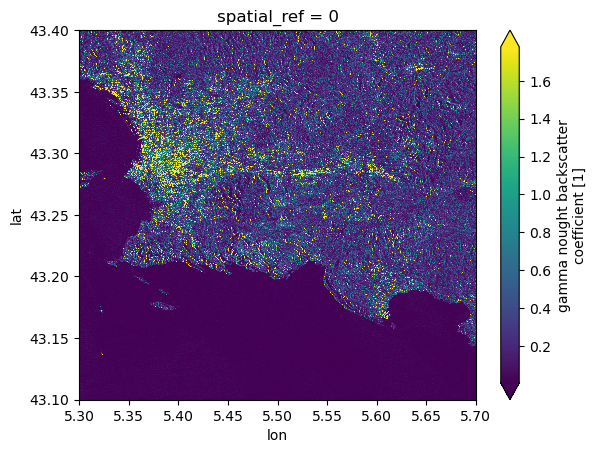

In [12]:
ds.gamma0_vv.plot(robust=True)

----

## Open a Sentinel-1 Level-1 SLC Product in Analysis Mode

Next, we show an example that accesses a Sentinel-1 Level-2 SLC product in **analysis mode**.

### Find a Sentinel-1 SLC Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-slc) to search for a Sentinel-1 SLC tile.

In [13]:
bbox = [5.3, 43.1, 5.7, 43.4]
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-1-l1-slc"],
        bbox=bbox,
        datetime=["2026-05-16", "2026-05-16"],
    ).items()
)
items

[<Item id=S1C_IW_SLC__1SDV_20260516T173005_20260516T173032_007682_00F9CB_945F>,
 <Item id=S1D_IW_SLC__1SDV_20260516T054355_20260516T054423_002805_004C18_0969>,
 <Item id=S1D_IW_SLC__1SDV_20260516T054330_20260516T054357_002805_004C18_FDBA>]

In [14]:
item = items[0]

In [15]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    bbox=bbox,
    chunks={}
)
ds

<xarray.Dataset> Size: 12MB
Dimensions:      (lat: 1081, lon: 1441)
Coordinates:
  * lat          (lat) float64 9kB 43.4 43.4 43.4 43.4 ... 43.1 43.1 43.1 43.1
  * lon          (lon) float64 12kB 5.3 5.3 5.301 5.301 ... 5.699 5.699 5.7 5.7
    spatial_ref  int64 8B ...
Data variables:
    gamma0_vv    (lat, lon) float32 6MB dask.array<chunksize=(1081, 1441), meta=np.ndarray>
    gamma0_vh    (lat, lon) float32 6MB dask.array<chunksize=(1081, 1441), meta=np.ndarray>

As an example, we plot the calibrated VV polarization band. Plotting triggers lazy loading and computation.

/home/konstantin/micromamba/envs/xarray-eopf/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


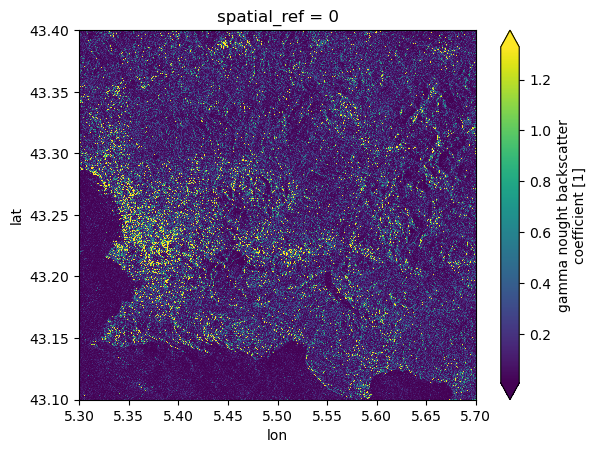

In [16]:
ds.gamma0_vv.plot(robust=True)

The same functionalities available for GRD products are also supported for SLC products, including the selection of different CRSs, bounding boxes, spatial resolutions, and interpolation methods.

----

## Open a Sentinel-1 Level-2 OCN Product in Analysis Mode

Next, we show an example that accesses a Sentinel-1 Level-2 OCN product in **analysis mode**.


### Find a Sentinel-1 OCN Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l2-ocn) to search for a Sentinel-1 OCN tile.

In [17]:
bbox = [3.0, 39.4, 3.2, 39.6]
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-1-l2-ocn"],
        bbox=bbox,
        datetime=["2025-07-01", "2025-08-01"],
    ).items()
)
items

[<Item id=S1A_IW_OCN__2SDV_20250730T055348_20250730T055413_060309_077EBE_1CA3>]

In [18]:
item = items[0]

In [19]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    chunks={},
)
ds

<xarray.Dataset> Size: 874kB
Dimensions:                   (lon: 293, lat: 212)
Coordinates:
  * lon                       (lon) float64 2kB 1.09 1.101 1.113 ... 4.432 4.444
  * lat                       (lat) float64 2kB 40.63 40.62 ... 38.74 38.73
    spatial_ref               int64 8B ...
Data variables:
    wind_direction            (lat, lon) float32 248kB dask.array<chunksize=(212, 293), meta=np.ndarray>
    wind_speed                (lat, lon) float32 248kB dask.array<chunksize=(212, 293), meta=np.ndarray>
    inversion_quality         (lat, lon) uint8 62kB dask.array<chunksize=(212, 293), meta=np.ndarray>
    percentage_bright_points  (lat, lon) float32 248kB dask.array<chunksize=(212, 293), meta=np.ndarray>
    wind_quality              (lat, lon) uint8 62kB dask.array<chunksize=(212, 293), meta=np.ndarray>
Attributes: (2)

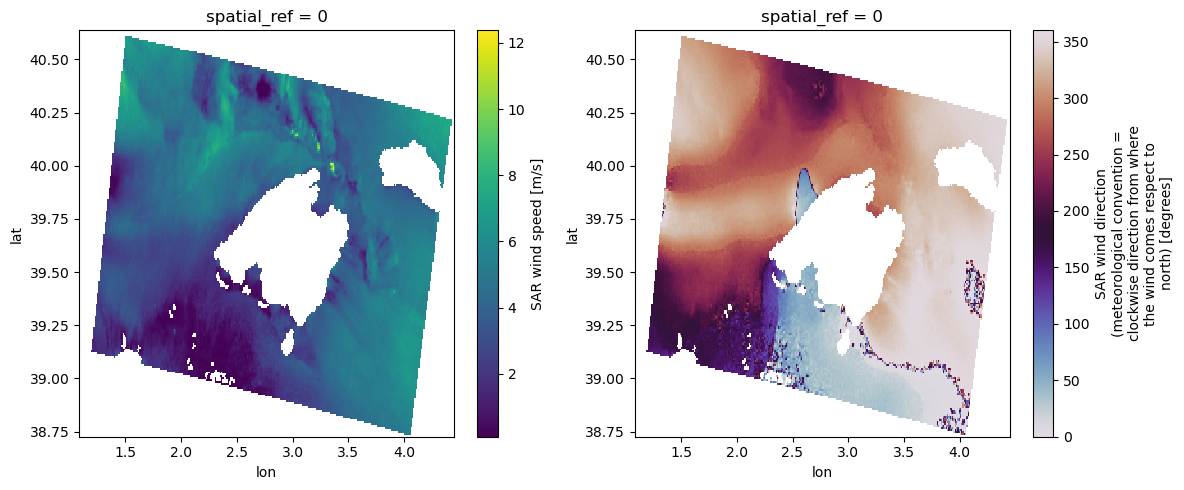

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ds.wind_speed.plot(ax=ax[0], cmap="viridis")
ds.wind_direction.plot(ax=ax[1], cmap="twilight", vmin=0, vmax=360)
plt.tight_layout()

We can also request the data in a different CRS, and define the target grid mapping by using the parameters `resolution`, and `bbox`.

In [21]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    crs="EPSG:32631",
    resolution=1_000, # meters
    bbox=[4e5, 4.3e6, 6e5, 4.5e6],
    variables=["wind_direction", "wind_speed"],
    chunks={},
)
ds

<xarray.Dataset> Size: 323kB
Dimensions:         (x: 200, y: 200)
Coordinates:
  * x               (x) float64 2kB 4.005e+05 4.015e+05 ... 5.985e+05 5.995e+05
  * y               (y) float64 2kB 4.5e+06 4.498e+06 ... 4.302e+06 4.3e+06
    spatial_ref     int64 8B ...
Data variables:
    wind_direction  (y, x) float32 160kB dask.array<chunksize=(200, 200), meta=np.ndarray>
    wind_speed      (y, x) float32 160kB dask.array<chunksize=(200, 200), meta=np.ndarray>
Attributes: (2)

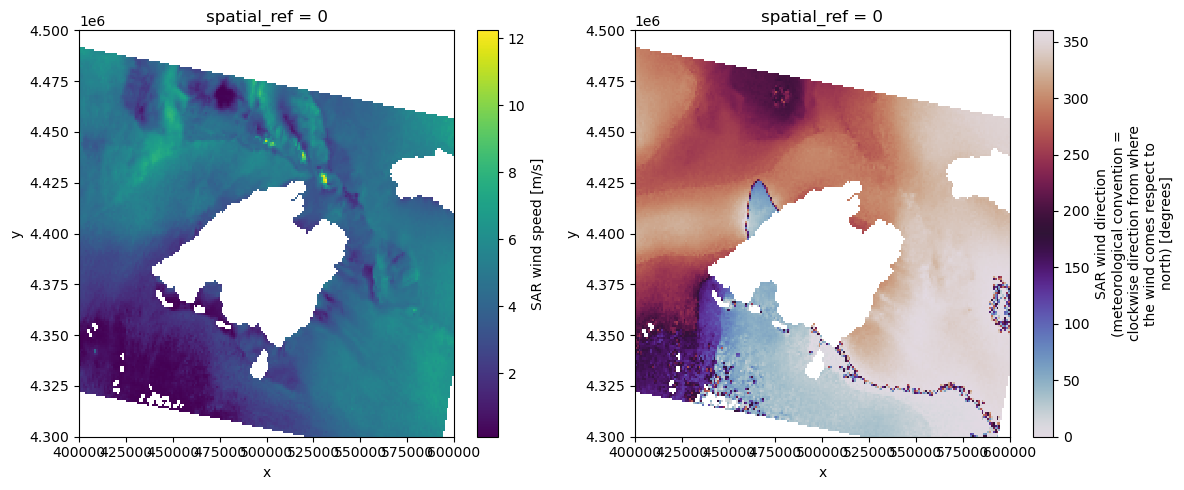

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ds.wind_speed.plot(ax=ax[0], cmap="viridis")
ds.wind_direction.plot(ax=ax[1], cmap="twilight", vmin=0, vmax=360)
plt.tight_layout()

## Conclusion

This notebook demonstrates how to access Sentinel-1 EOPF Zarr samples in **analysis mode** using the **xarray-eopf** plugin. The key takeaways are:

- **Analysis mode** is the default `op_mode` and does not need to be explicitly specified.
- The analysis mode for **Sentinel-1 Level-1 GRD** consists of:
  - **Radiometric calibration** using LUTs
  - **Geometric Terrain Correction (GTC)** via inverse geocoding using orbit information and a DEM
  - Optional **Radiometric Terrain Correction (RTC)** to reduce terrain-induced radiometric distortions
  - A DEM can be:
    - explicitly provided by the user, or
    - automatically retrieved from the CDSE STAC API
  - Data is accessed lazily and processed at a **user-defined resolution, bounding box, and CRS**, enabling flexible subsetting, resampling, and reprojection.
    - When a DEM is provided, the output grid is derived directly from the DEM grid definition.
- The analysis workflow for **Sentinel-1 Level-2 OCN** includes:
  - Rectification of the data from an irregular latitude/longitude swath grid to a regular target grid
  - User-defined target grids via parameters `crs`, `bbox`, `resolution`
  - Automatic inclusion of quality flag variables by default
  - Optional variable selection through the `variables` parameter

> **Note:** This notebook only covers **analysis mode** for Sentinel-1. To learn more about **native mode**, see the [Sentinel-1 native mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_1_native/).


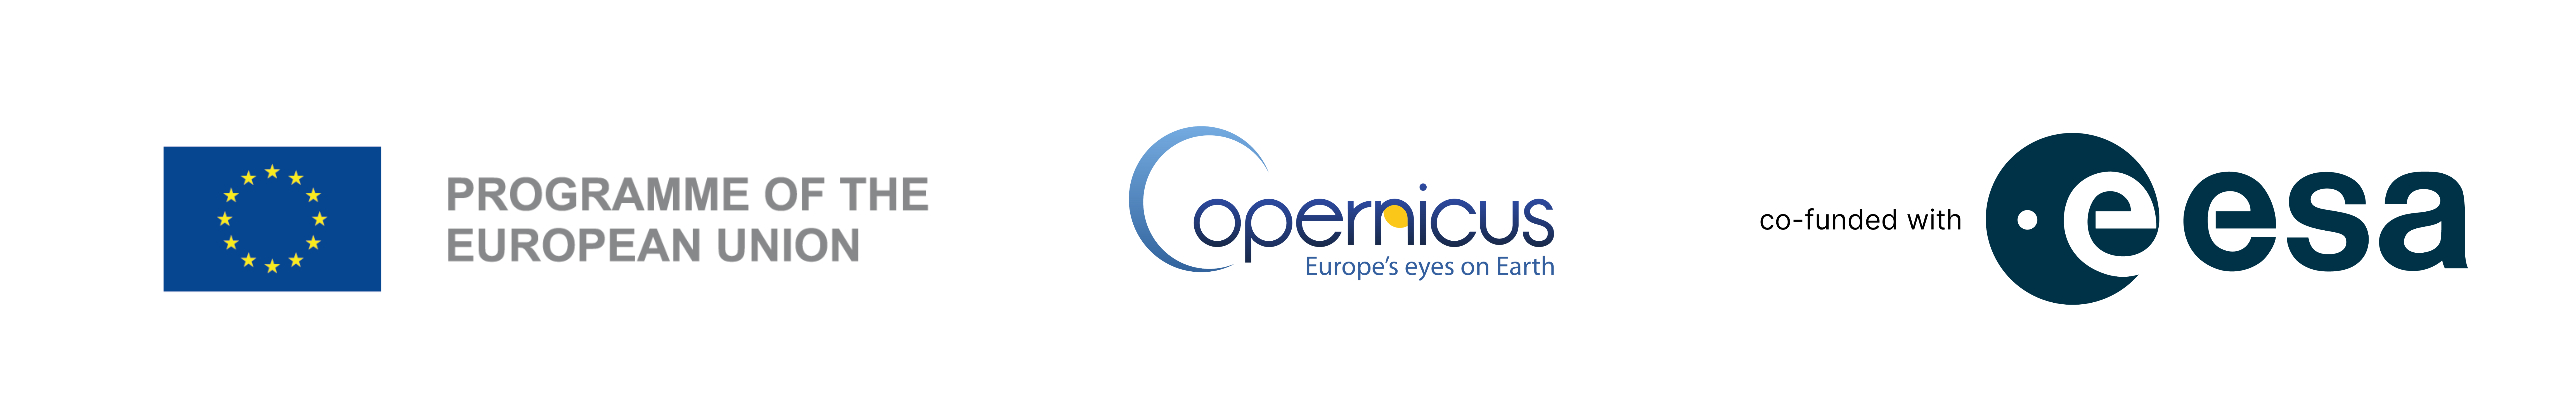